In [ ]:
!pip install yfinance -q

In [1]:
!pip install arch -q

In [81]:
import pandas as pd
import numpy as np 
import yfinance as yf
from arch import arch_model
import matplotlib.pyplot as plt
import statsmodels

In [82]:
data=pd.read_csv(r'..\..\data\raw\data_2008.csv', index_col=0, parse_dates=True)

In [83]:

# 1. 데이터(data)에서의 결측치 확인
final_na_counts = data.isna().sum()

print("--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---")
print(final_na_counts)

print("\n--- 데이터 품질 검증 (시작일 및 샘플) ---")
for col in data.columns:
    first_valid = data[col].first_valid_index()
    last_val = data[col].iloc[-1]
    print(f"{col:15} | 시작일: {first_valid.date()} | 최근값: {last_val:10.2f} | 남은 NaN: {data[col].loc[first_valid:].isna().sum()}")

# 전체 행 수 출력
print(f"\n전체 타임라인 행 수: {len(data)}")

--- [최종 정제 데이터] 항목별 결측치(NaN) 개수 ---
Shanghai Comp        0
KODEX 200          320
TOPIX                2
Brent Crude Oil      0
USD/CNY              0
Gold Spot            0
JPY/KRW              0
USD/KRW              0
NASDAQ               0
KOSDAQ               0
KOSPI 200 Close      0
KOSPI 200 Open       0
KOSPI 200 High       0
KOSPI 200 Low        0
CNY/KRW              0
dtype: int64

--- 데이터 품질 검증 (시작일 및 샘플) ---
Shanghai Comp   | 시작일: 2008-01-02 | 최근값:    4162.88 | 남은 NaN: 0
KODEX 200       | 시작일: 2009-04-17 | 최근값:   94120.00 | 남은 NaN: 0
TOPIX           | 시작일: 2008-01-04 | 최근값:    4131.00 | 남은 NaN: 0
Brent Crude Oil | 시작일: 2008-01-02 | 최근값:      72.48 | 남은 NaN: 0
USD/CNY         | 시작일: 2008-01-02 | 최근값:       6.84 | 남은 NaN: 0
Gold Spot       | 시작일: 2008-01-02 | 최근값:    5230.50 | 남은 NaN: 0
JPY/KRW         | 시작일: 2008-01-02 | 최근값:       9.19 | 남은 NaN: 0
USD/KRW         | 시작일: 2008-01-02 | 최근값:    1432.32 | 남은 NaN: 0
NASDAQ          | 시작일: 2008-01-02 | 최근값:   22668.21 | 남은 NaN: 0


### 로그 수익률 계산 및 정상성(ADF) 검정

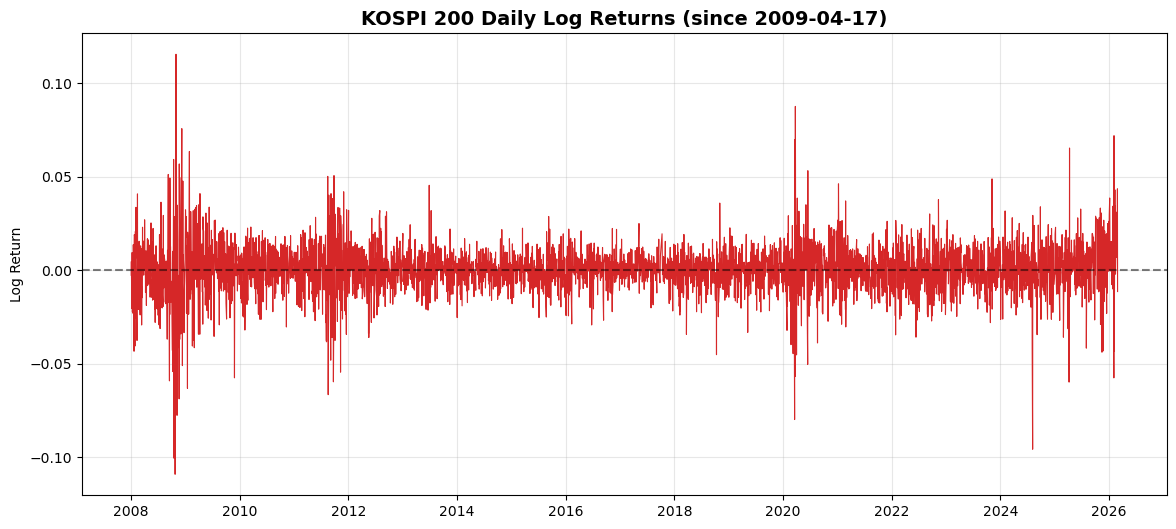

--- KOSPI 200 로그 수익률 기초 통계 ---


count    4428.000000
mean        0.000311
std         0.013063
min        -0.109029
25%        -0.005881
50%         0.000594
75%         0.006923
max         0.115397
Name: KOSPI 200_Log_Return, dtype: float64

In [84]:
# KOSPI 200 로그 수익률 계산: ln(Pt / Pt-1)
# 데이터가 정렬된 상태이므로 shift(1)을 사용하여 계산합니다.
data['KOSPI 200_Log_Return'] = np.log(data['KOSPI 200 Close'] / data['KOSPI 200 Close'].shift(1))

# 시각화
plt.figure(figsize=(14, 6))
plt.plot(data.index, data['KOSPI 200_Log_Return'], color='tab:red', linewidth=0.8)
plt.title('KOSPI 200 Daily Log Returns (since 2009-04-17)', fontsize=14, fontweight='bold')
plt.ylabel('Log Return')
plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.grid(True, alpha=0.3)
plt.show()

# 기초 통계량 출력
print("--- KOSPI 200 로그 수익률 기초 통계 ---")
display(data['KOSPI 200_Log_Return'].describe())


In [86]:
#data를 2009-04-17 이후로 자르기
data = data.loc['2009-04-17':]
data.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 4109 entries, 2009-04-17 to 2026-02-27
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Shanghai Comp         4109 non-null   float64
 1   KODEX 200             4109 non-null   float64
 2   TOPIX                 4109 non-null   float64
 3   Brent Crude Oil       4109 non-null   float64
 4   USD/CNY               4109 non-null   float64
 5   Gold Spot             4109 non-null   float64
 6   JPY/KRW               4109 non-null   float64
 7   USD/KRW               4109 non-null   float64
 8   NASDAQ                4109 non-null   float64
 9   KOSDAQ                4109 non-null   float64
 10  KOSPI 200 Close       4109 non-null   float64
 11  KOSPI 200 Open        4109 non-null   float64
 12  KOSPI 200 High        4109 non-null   float64
 13  KOSPI 200 Low         4109 non-null   float64
 14  CNY/KRW               4109 non-null   float64
 15  KOSPI 200_Log_

In [87]:
#로그 수익률 정상성 검정

from statsmodels.tsa.stattools import adfuller

#로그 수익률 검정을 위해 추출 
returns_series = data['KOSPI 200_Log_Return'].dropna()

# ADF 검정 수행 
#귀무가설 H0: 시계열이 비정상적이다 (Unit Root 존재)
result = adfuller(returns_series)

print('--- KOSPI 200 로그 수익률 ADF 검정 결과 ---')
print(f'ADF Statistic: {result[0]:.4f}')
print(f'p-value: {result[1]:.4e}')
print('Critical Values:')
for key, value in result[4].items():
    print(f'\t{key}: {value:.4f}')

if result[1] < 0.05:
    print('\n결과 해석: p-value가 0.05보다 작으므로, 유의수준 5%에서 귀무가설을 기각합니다. 즉, 데이터는 정상성(Stationarity)을 가집니다.')
else:
    print('\n결과 해석: p-value가 0.05보다 크므로, 귀무가설을 기각할 수 없습니다. 데이터가 비정상(Non-stationary)일 가능성이 높습니다.')

--- KOSPI 200 로그 수익률 ADF 검정 결과 ---
ADF Statistic: -64.4904
p-value: 0.0000e+00
Critical Values:
	1%: -3.4319
	5%: -2.8622
	10%: -2.5671

결과 해석: p-value가 0.05보다 작으므로, 유의수준 5%에서 귀무가설을 기각합니다. 즉, 데이터는 정상성(Stationarity)을 가집니다.


### ARIMA 모델 확인

In [88]:
#ARMA 모델 시뮬레이션. 최적 파라미터 (0,0,0). 화이트 노이즈에 가깝다고 결론 내림. @성택

import itertools
import pandas as pd
from statsmodels.tsa.arima.model import ARIMA

# 1. 탐색할 파라미터 범위 설정 (p, d, q)
p = range(0, 4)  # AR 차수
d = [0]          # 이미 로그 수익률이므로 차분은 0으로 고정
q = range(0, 4)  # MA 차수

# p, d, q 조합 생성
pdq = list(itertools.product(p, d, q))

returns = data['KOSPI 200_Log_Return'].dropna()
best_aic = float("inf")
best_order = None
best_model = None

print("--- ARIMA 최적 모수 그리드 서치 시작 ---")

# 2. 각 조합별 모델 적합 및 AIC 계산
for order in pdq:
    try:
        model = ARIMA(returns, order=order)
        results = model.fit()
        if results.aic < best_aic:
            best_aic = results.aic
            best_order = order
            best_model = results
        print(f'ARIMA{order} - AIC: {results.aic:.2f}')
    except:
        continue

print(f"\n[최적 결과] Best ARIMA Order: {best_order} with AIC: {best_aic:.2f}")

# 3. 최적 모델 상세 요약 출력
print("\n--- 최적 모델 상세 요약 ---")
print(best_model.summary())

--- ARIMA 최적 모수 그리드 서치 시작 ---
ARIMA(0, 0, 0) - AIC: -24871.24
ARIMA(0, 0, 1) - AIC: -24869.41
ARIMA(0, 0, 2) - AIC: -24867.87
ARIMA(0, 0, 3) - AIC: -24866.03
ARIMA(1, 0, 0) - AIC: -24869.42
ARIMA(1, 0, 1) - AIC: -24867.40
ARIMA(1, 0, 2) - AIC: -24865.69
ARIMA(1, 0, 3) - AIC: -24863.24
ARIMA(2, 0, 0) - AIC: -24867.86
ARIMA(2, 0, 1) - AIC: -24865.90
ARIMA(2, 0, 2) - AIC: -24863.63
ARIMA(2, 0, 3) - AIC: -24861.24
ARIMA(3, 0, 0) - AIC: -24866.05
ARIMA(3, 0, 1) - AIC: -24864.05
ARIMA(3, 0, 2) - AIC: -24863.16
ARIMA(3, 0, 3) - AIC: -24859.24

[최적 결과] Best ARIMA Order: (0, 0, 0) with AIC: -24871.24

--- 최적 모델 상세 요약 ---
                                SARIMAX Results                                 
Dep. Variable:     KOSPI 200_Log_Return   No. Observations:                 4109
Model:                            ARIMA   Log Likelihood               12437.620
Date:                  Mon, 30 Mar 2026   AIC                         -24871.239
Time:                          20:57:07   BIC           

### ARCH 적용 검정 : 잔차 제곱의 자기상관이 존재하는가?

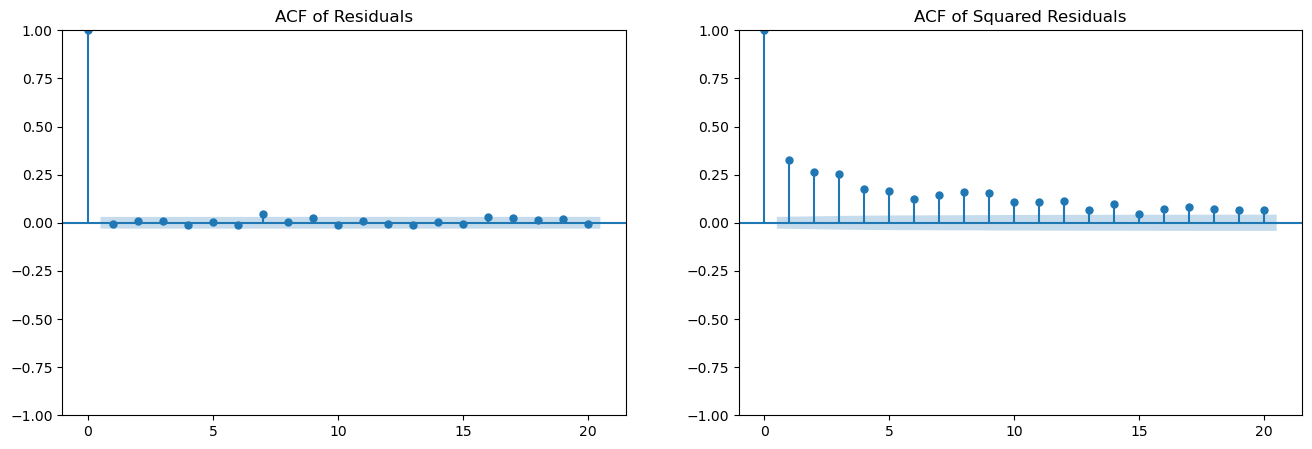

--- ARCH 효과 검정 (Ljung-Box Test on Squared Residuals) ---


,lb_stat,lb_pvalue
10,1619.549314,0.0



결과 해석: p-value(0.0000e+00)가 0.05보다 작으므로 잔차 제곱에 자기상관이 존재합니다.
즉, ARCH 효과가 존재하며 GARCH 모델링을 통한 변동성 분석이 적절합니다.


In [89]:
#GARCH 적용이 적절한지 ARCH 효과 검정

import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# 1. 잔차(Residuals) 계산 (ARMA(0,0,0)이므로 수익률에서 평균을 뺀 값)
log_returns = data['KOSPI 200_Log_Return']
residuals = log_returns - log_returns.mean()
squared_residuals = residuals**2 #잔차 제곱 계산

# 2. 잔차 제곱의 자기상관 시각화 (ACF)
fig, ax = plt.subplots(1, 2, figsize=(16, 5))
sm.graphics.tsa.plot_acf(residuals, lags=20, ax=ax[0], title='ACF of Residuals')
sm.graphics.tsa.plot_acf(squared_residuals, lags=20, ax=ax[1], title='ACF of Squared Residuals')
plt.show()

# 3. Ljung-Box 검정을 통한 ARCH 효과(이분산성) 확인
#잔체 제곱에 대해서
lb_test = acorr_ljungbox(squared_residuals, lags=[10], return_df=True)

print("--- ARCH 효과 검정 (Ljung-Box Test on Squared Residuals) ---")
display(lb_test)

if lb_test['lb_pvalue'].iloc[0] < 0.05:
    print(f"\n결과 해석: p-value({lb_test['lb_pvalue'].iloc[0]:.4e})가 0.05보다 작으므로 잔차 제곱에 자기상관이 존재합니다.")
    print("즉, ARCH 효과가 존재하며 GARCH 모델링을 통한 변동성 분석이 적절합니다.")
else:
    print("\n결과 해석: ARCH 효과가 뚜렷하지 않습니다. GARCH 모델링의 실익이 적을 수 있습니다.")

### GARCH 모델링

In [91]:
import itertools
import pandas as pd
from arch import arch_model
import warnings
warnings.filterwarnings('ignore')

# 1. 탐색할 GARCH 파라미터 범위 설정 (p, q)
p_range = range(1, 4)
q_range = range(1, 4)
pq_combinations = list(itertools.product(p_range, q_range))

#안정성을 위해 100 곱함
returns = data['KOSPI 200_Log_Return'].dropna() * 100 #퍼센트 단위로 변환

best_aic = float('inf')
best_pq = None
best_garch_res = None

print('--- GARCH 최적 모수 그리드 서치 시작 ---')

# 2. 각 조합별 모델 적합 및 AIC 비교
for p, q in pq_combinations:
    try:
        model = arch_model(returns, vol='Garch', p=p, q=q, dist='t') #t-분포로 가정
        res = model.fit(disp='off')
        if res.aic < best_aic:
            best_aic = res.aic
            best_pq = (p, q)
            best_garch_res = res
        print(f'GARCH({p}, {q}) - AIC: {res.aic:.2f}')
    except:
        continue

print(f'\n[최적 결과] Best GARCH Order: {best_pq} with AIC: {best_aic:.2f}')

# 3. 최적 모델 상세 요약 및 Alpha+Beta 계산
print('\n--- 최적 GARCH 모델 상세 요약 ---')
print(best_garch_res.summary())

# 최적 모델의 Persistence 계산 (모든 alpha와 beta의 합)
params = best_garch_res.params
persistence = sum([params[k] for k in params.keys() if 'alpha' in k or 'beta' in k])
print(f'\nTotal Persistence (Sum of Alphas and Betas): {persistence:.4f}')

--- GARCH 최적 모수 그리드 서치 시작 ---
GARCH(1, 1) - AIC: 11940.47
GARCH(1, 2) - AIC: 11942.47
GARCH(1, 3) - AIC: 11943.90
GARCH(2, 1) - AIC: 11942.47
GARCH(2, 2) - AIC: 11943.97
GARCH(2, 3) - AIC: 11940.94
GARCH(3, 1) - AIC: 11944.47
GARCH(3, 2) - AIC: 11945.97
GARCH(3, 3) - AIC: 11942.88

[최적 결과] Best GARCH Order: (1, 1) with AIC: 11940.47

--- 최적 GARCH 모델 상세 요약 ---
                        Constant Mean - GARCH Model Results                         
Dep. Variable:         KOSPI 200_Log_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                            GARCH   Log-Likelihood:               -5965.23
Distribution:      Standardized Student's t   AIC:                           11940.5
Method:                  Maximum Likelihood   BIC:                           11972.1
                                              No. Observations:                 4109
Date:                      Mon, Mar 30 2026

--- GARCH 모델 파라미터 및 지속성 분석 ---
Alpha Sum: 0.0724
Beta Sum:  0.9130
Total Persistence (Alpha + Beta): 0.9854

--- 표준화된 잔차 제곱의 Ljung-Box 검정 (ARCH 효과 제거 확인) ---


,lb_stat,lb_pvalue
10,11.999483,0.285091



결과: p-value(0.2851)가 0.05보다 크므로 변동성 구조가 잘 잡혔습니다.


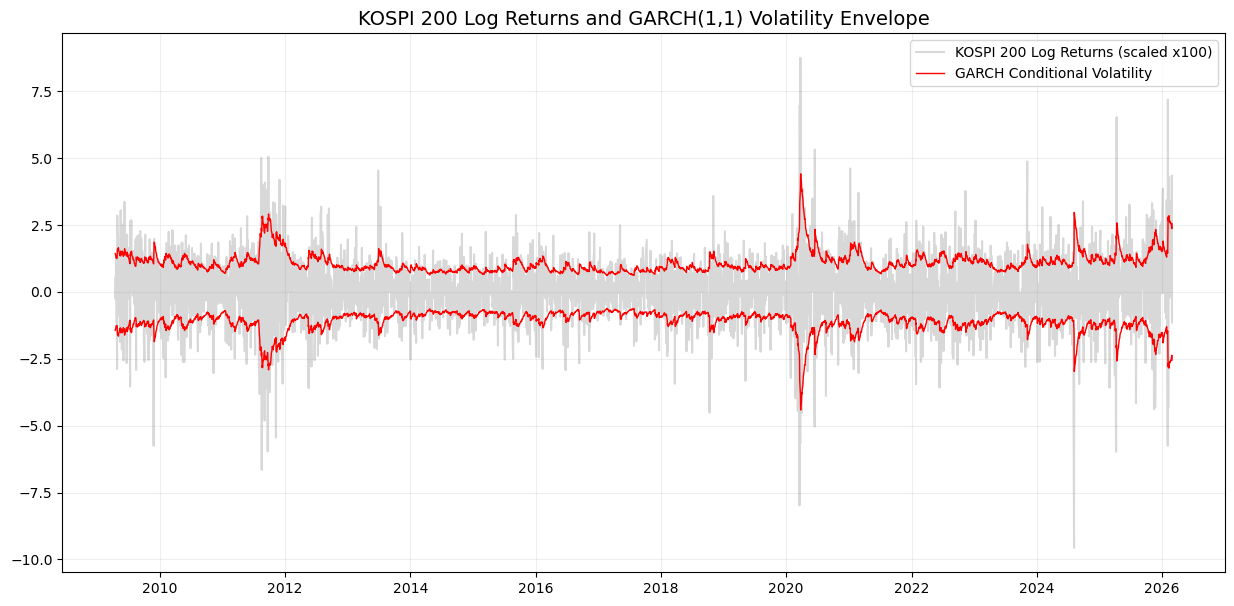

In [92]:
#GARCH 잔차 분석 및 alpha + Beta 값 확인

from statsmodels.stats.diagnostic import acorr_ljungbox
import matplotlib.pyplot as plt

# 1. 최적 모델(best_garch_res)에서 파라미터 및 잔차 추출
# 앞선 셀에서 best_garch_res가 정의되어 있어야 함
params = best_garch_res.params
alpha_sum = sum([params[k] for k in params.keys() if 'alpha' in k])
beta_sum = sum([params[k] for k in params.keys() if 'beta' in k])
persistence = alpha_sum + beta_sum

print(f"--- GARCH 모델 파라미터 및 지속성 분석 ---")
print(f"Alpha Sum: {alpha_sum:.4f}")
print(f"Beta Sum:  {beta_sum:.4f}")
print(f"Total Persistence (Alpha + Beta): {persistence:.4f}")

# 2. 표준화된 잔차(Standardized Residuals) 진단
std_resid = best_garch_res.resid / best_garch_res.conditional_volatility
#귀무가설 H_0: 표준화된 잔차 제곱에 자기상관이 없다 (ARCH 효과 제거 성공)
lb_test_resid = acorr_ljungbox(std_resid**2, lags=[10], return_df=True) #Ljung-Box 검정으로 표준화된 잔차 제곱의 자기상관 확인 

print("\n--- 표준화된 잔차 제곱의 Ljung-Box 검정 (ARCH 효과 제거 확인) ---")
display(lb_test_resid)

if lb_test_resid['lb_pvalue'].iloc[0] > 0.05:
    print(f"\n결과: p-value({lb_test_resid['lb_pvalue'].iloc[0]:.4f})가 0.05보다 크므로 변동성 구조가 잘 잡혔습니다.")
else:
    print("\n결과: 잔차에 여전히 자기상관이 남아있습니다.")

# 3. 원본 로그 수익률 vs GARCH 변동성 플랏
plt.figure(figsize=(15, 7))
plt.plot(returns, color='gray', alpha=0.3, label='KOSPI 200 Log Returns (scaled x100)')
plt.plot(best_garch_res.conditional_volatility, color='red', linewidth=1, label='GARCH Conditional Volatility')
plt.plot(-best_garch_res.conditional_volatility, color='red', linewidth=1)
plt.title(f'KOSPI 200 Log Returns and GARCH({best_pq[0]},{best_pq[1]}) Volatility Envelope', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### GJR-GARCH 모델링

--- GJR-GARCH 최적 모수 그리드 서치 시작 ---
GJR-GARCH(1, 1, 1) - AIC: 11906.45
GJR-GARCH(1, 1, 2) - AIC: 11908.01
GJR-GARCH(2, 1, 1) - AIC: 11907.80
GJR-GARCH(2, 1, 2) - AIC: 11905.09

[최적 결과] Best GJR-GARCH Order: (2, 1, 2) with AIC: 11905.09

--- 최적 GJR-GARCH 모델 상세 요약 ---
                      Constant Mean - GJR-GARCH Model Results                       
Dep. Variable:         KOSPI 200_Log_Return   R-squared:                       0.000
Mean Model:                   Constant Mean   Adj. R-squared:                  0.000
Vol Model:                        GJR-GARCH   Log-Likelihood:               -5944.55
Distribution:      Standardized Student's t   AIC:                           11905.1
Method:                  Maximum Likelihood   BIC:                           11955.7
                                              No. Observations:                 4109
Date:                      Mon, Mar 30 2026   Df Residuals:                     4108
Time:                              21:04:23   Df Model:

,lb_stat,lb_pvalue
10,10.693188,0.381916


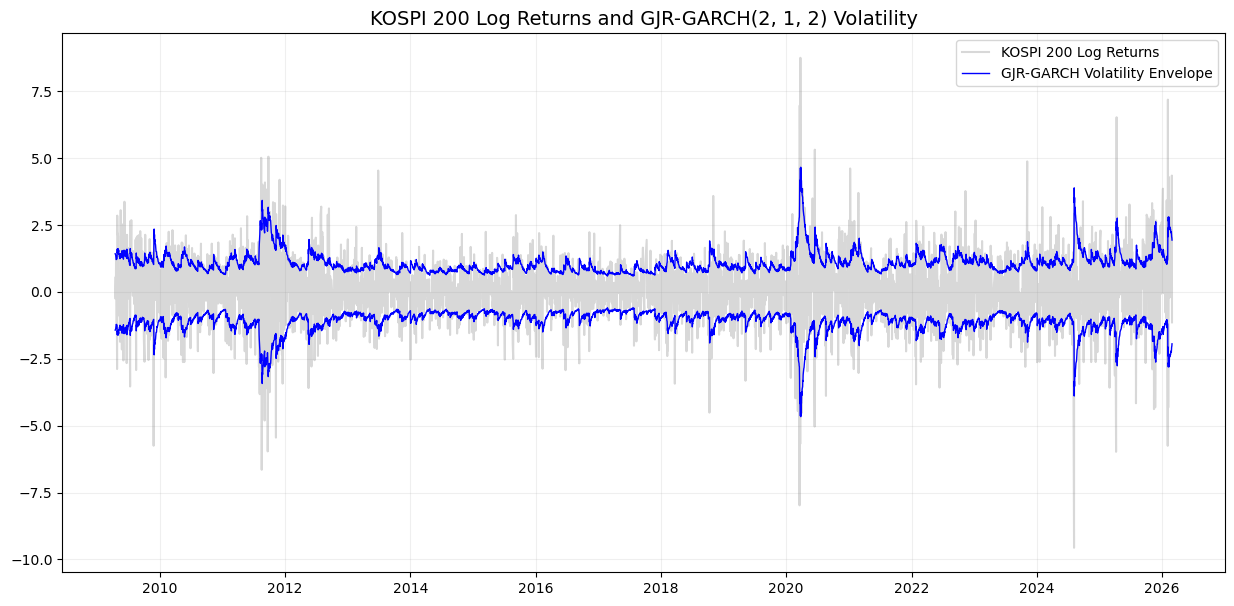

In [95]:
#GJR_GARCH 모델링

import itertools
import pandas as pd
from arch import arch_model
import matplotlib.pyplot as plt
from statsmodels.stats.diagnostic import acorr_ljungbox

# 1. GJR-GARCH 최적 모수 그리드 서치 (p, o, q)
# o는 비대칭 항(leverage term)의 차수입니다.
p_range = range(1, 3)
o_range = [1] # 비대칭 효과를 확인하기 위해 1로 고정
q_range = range(1, 3)
p_o_q_combinations = list(itertools.product(p_range, o_range, q_range))

returns = data['KOSPI 200_Log_Return'].dropna() * 100

best_gjr_aic = float('inf')
best_gjr_pq = None
best_gjr_res = None

print('--- GJR-GARCH 최적 모수 그리드 서치 시작 ---')

for p, o, q in p_o_q_combinations:
    try:
        # p: Lagged squared error, o: Lagged asymmetric error, q: Lagged variance
        model = arch_model(returns, vol='Garch', p=p, o=o, q=q, dist='t')
        res_gjr = model.fit(disp='off') 
        if res_gjr.aic < best_gjr_aic:
            best_gjr_aic = res_gjr.aic
            best_gjr_pq = (p, o, q)
            best_gjr_res = res_gjr
        print(f'GJR-GARCH({p}, {o}, {q}) - AIC: {res_gjr.aic:.2f}')
    except:
        continue

print(f'\n[최적 결과] Best GJR-GARCH Order: {best_gjr_pq} with AIC: {best_gjr_aic:.2f}')

# 2. 최적 모델 결과 및 비대칭 계수(Gamma) 확인
print('\n--- 최적 GJR-GARCH 모델 상세 요약 ---')
print(best_gjr_res.summary())

# gamma[1] 계수가 양수이고 유의미하면 하락장에서 변동성이 더 커지는 레버리지 효과가 존재함
gamma = best_gjr_res.params.get('gamma[1]', 0)
print(f'\nAsymmetric Coefficient (Gamma[1]): {gamma:.4f}')

# 3. 잔차 진단 및 시각화
std_resid_gjr = best_gjr_res.resid / best_gjr_res.conditional_volatility
#귀무가설 H_0: 표준화된 잔차 제곱에 자기상관이 없다 (GARCH 효과 제거 성공)
lb_test_gjr = acorr_ljungbox(std_resid_gjr**2, lags=[10], return_df=True)

print("\n--- 표준화된 잔차 제곱의 Ljung-Box 검정 ---")
display(lb_test_gjr)

plt.figure(figsize=(15, 7))
plt.plot(returns, color='gray', alpha=0.3, label='KOSPI 200 Log Returns')
plt.plot(best_gjr_res.conditional_volatility, color='blue', linewidth=1, label='GJR-GARCH Volatility Envelope')
plt.plot(-best_gjr_res.conditional_volatility, color='blue', linewidth=1)
plt.title(f'KOSPI 200 Log Returns and GJR-GARCH{best_gjr_pq} Volatility', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.2)
plt.show()

### GARCH VaR 계산

In [96]:
#var_series 계산
#적합된 GARCH 모델을 사용하여 전체 기간의 VaR 시계열 계산

import numpy as np
from scipy.stats import t

# 1. GARCH 모델로부터 전체 기간의 조건부 변동성 추출
sigma_series = best_garch_res.conditional_volatility

# 2. 전체 기간의 조건부 평균 (보통 상수항 mu 사용)
mu_series = best_garch_res.params.get('mu', 0.0)

# 3. Student's t-분포의 임계값 (z_alpha, alpha=0.05)
nu = best_garch_res.params['nu']
z_alpha = t.ppf(0.05, nu) * np.sqrt((nu - 2) / nu)

# 4. 전체 기간의 VaR 시계열 계산
garch_var_series = mu_series + (z_alpha * sigma_series)

# 결과 확인
print(garch_var_series.head(10))

Date
2009-04-17   -2.233272
2009-04-20   -2.147509
2009-04-21   -2.073993
2009-04-22   -1.995638
2009-04-23   -2.002732
2009-04-24   -1.965966
2009-04-27   -1.957618
2009-04-28   -1.950800
2009-04-29   -2.251586
2009-04-30   -2.467166
Name: cond_vol, dtype: float64


### gjr-GARCH VaR 계산

In [97]:
# @찬재 var_series 계산
#적합된 GJR-GARCH 모델을 사용하여 전체 기간의 VaR 시계열 계산

import numpy as np
from scipy.stats import t

# 1. GJR-GARCH 모델로부터 전체 기간의 조건부 변동성 추출
gjr_var_sigma_series = best_gjr_res.conditional_volatility

# 2. 전체 기간의 조건부 평균 (보통 상수항 mu 사용)
gjr_mu_series = best_gjr_res.params.get('mu', 0.0)

# 3. Student's t-분포의 임계값 (gjr_z_alpha, alpha=0.05)
gjr_nu = best_gjr_res.params['nu']
gjr_z_alpha = t.ppf(0.05, gjr_nu) * np.sqrt((gjr_nu - 2) / gjr_nu)

# 4. 전체 기간의 VaR 시계열 계산
gjr_var_series = gjr_mu_series + (gjr_z_alpha * gjr_var_sigma_series)

# 결과 확인
print(gjr_var_series.head(10))

Date
2009-04-17   -2.246073
2009-04-20   -2.169582
2009-04-21   -2.062932
2009-04-22   -2.000966
2009-04-23   -1.900311
2009-04-24   -1.915770
2009-04-27   -1.936768
2009-04-28   -1.972482
2009-04-29   -2.529184
2009-04-30   -2.284930
Name: cond_vol, dtype: float64


### gjr-VaR 플랏

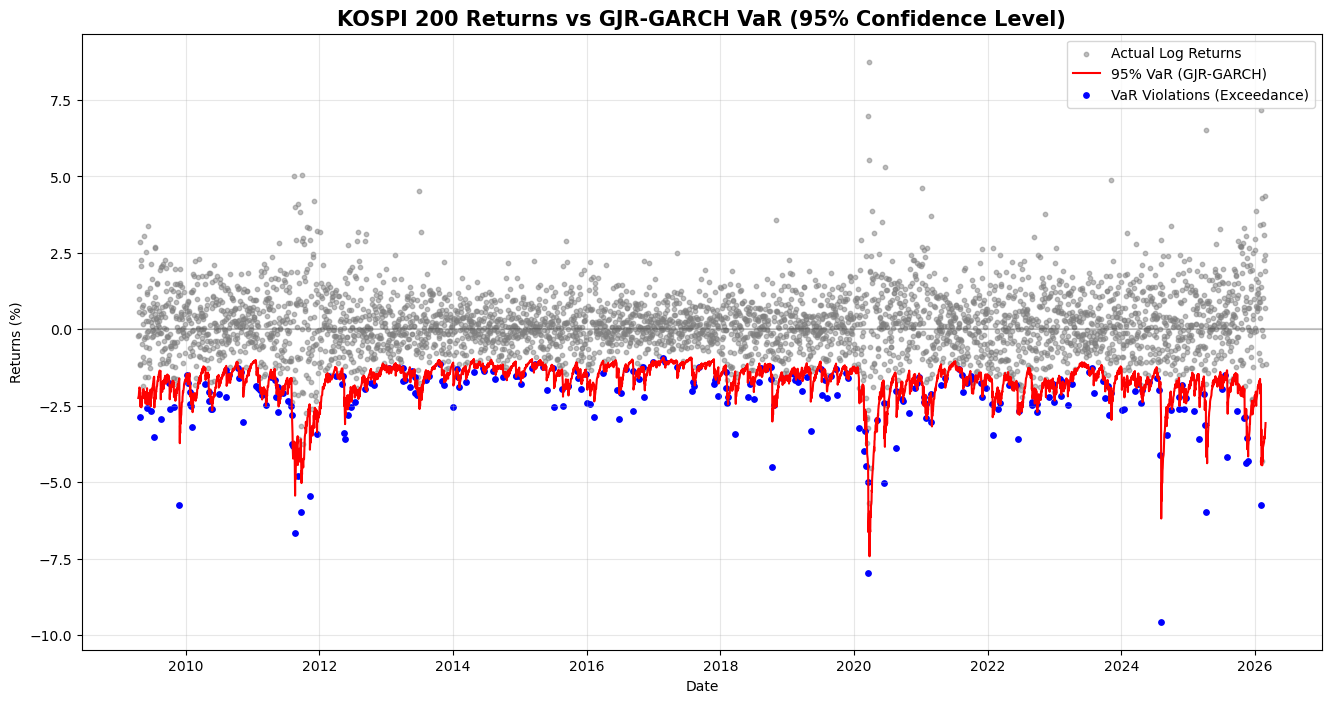

--- VaR Violation 요약 ---
총 거래일: 4109일
VaR 초과 횟수: 259회
초과율: 6.30%


In [98]:
# gjr-VaR plotting

import matplotlib.pyplot as plt

# 1. 이전 단계에서 계산된 VaR 시리즈(var_series)와 수익률(returns) 준비
# var_series는 이미 GJR-GARCH 모델의 mu + (z_alpha * sigma)로 계산되어 있습니다.

plt.figure(figsize=(16, 8))

# 2. 실제 로그 수익률을 점(scatter)으로 표시
plt.scatter(returns.index, returns.values, color='gray', s=10, alpha=0.5, label='Actual Log Returns')

# 3. 95% VaR 임계값을 선(line)으로 표시
plt.plot(gjr_var_series.index, gjr_var_series.values, color='red', linewidth=1.5, label='95% VaR (GJR-GARCH)')

# 4. VaR을 초과한(더 큰 손실을 본) 지점 강조
violations = returns[returns < gjr_var_series]
plt.scatter(violations.index, violations.values, color='blue', s=15, label='VaR Violations (Exceedance)')

plt.title('KOSPI 200 Returns vs GJR-GARCH VaR (95% Confidence Level)', fontsize=15, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Returns (%)')
plt.legend(loc='upper right')
plt.grid(True, alpha=0.3)
plt.axhline(0, color='black', linestyle='-', alpha=0.2)

plt.show()

print(f"--- VaR Violation 요약 ---")
print(f"총 거래일: {len(returns)}일")
print(f"VaR 초과 횟수: {len(violations)}회")
print(f"초과율: {(len(violations)/len(returns))*100:.2f}%")

### gjr-VaR tr/val/test 나누기

In [99]:
# 1. Threshold 설정 (@ 찬재 VaR 위반한 returns 중 최댓값)
# returns와 var_series 인덱스 맞추기
tmp = pd.concat([returns.rename("return"), gjr_var_series.rename("gjr-VaR")], axis=1).dropna()
tmp.head()

,return,gjr-VaR
Date,,
2009-04-17,-0.233192,-2.246073
2009-04-20,0.564563,-2.169582
2009-04-21,-0.197523,-2.062932
2009-04-22,1.408955,-2.000966
2009-04-23,0.992765,-1.900311


In [100]:
#train/validation/test를 5:3:2로 나누기
total_len = len(tmp)
train_end = int(total_len * 0.5)
val_end = int(total_len * 0.8)
train_data = tmp.iloc[:train_end]
val_data = tmp.iloc[train_end:val_end]
test_data = tmp.iloc[val_end:]


In [101]:
#train set에서 VaR보다 작은 값중에 가장 큰 것을 threshold로 설정
threshold = train_data[train_data['return'] < train_data['gjr-VaR']]['return'].max()
threshold

-0.9240442267336526

In [102]:
train_data.head()

,return,gjr-VaR
Date,,
2009-04-17,-0.233192,-2.246073
2009-04-20,0.564563,-2.169582
2009-04-21,-0.197523,-2.062932
2009-04-22,1.408955,-2.000966
2009-04-23,0.992765,-1.900311


### train threshold로 label 분류 및 시각화

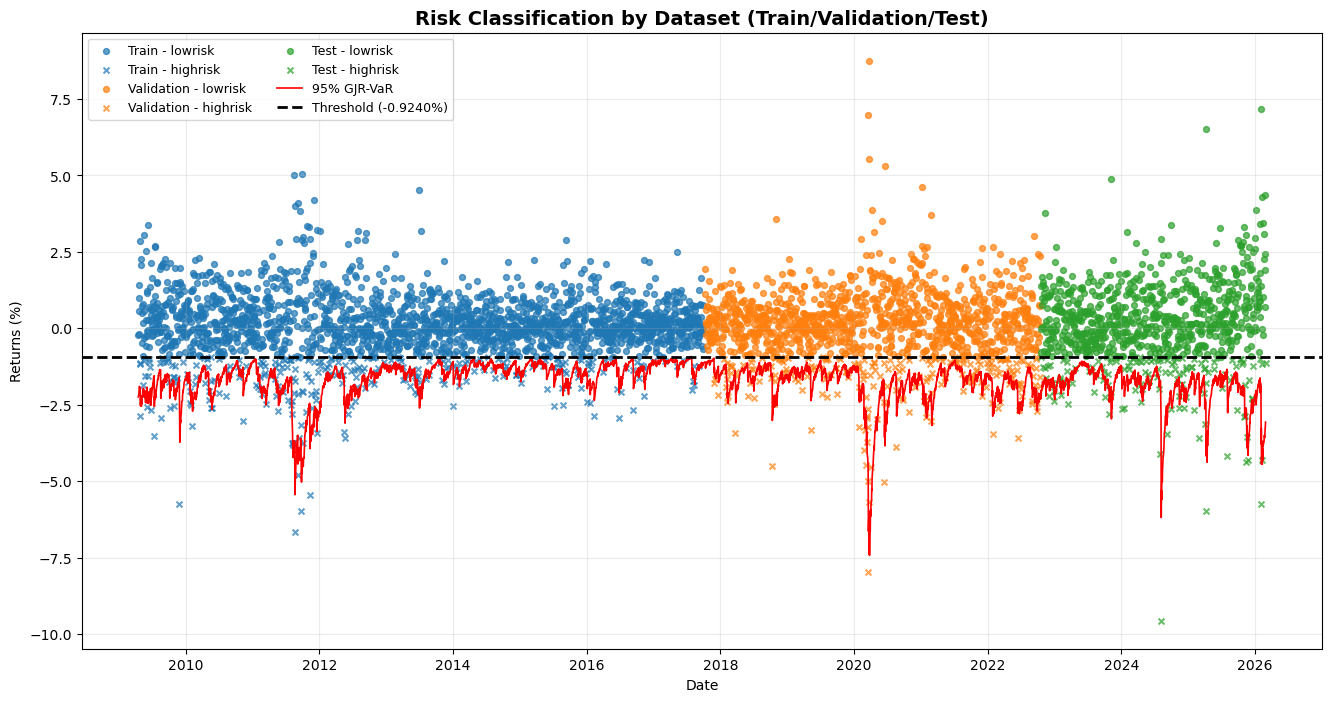

Threshold: -0.9240%


Risk_Label,highrisk,lowrisk,highrisk_ratio(%)
Set,,,
Test,139,683,16.91
Train,290,1764,14.12
Validation,233,1000,18.90


In [103]:
# train/validation/test 데이터 정합성 확인 및 정렬
required_cols = {"return", "gjr-VaR"}
for name, df in {"train_data": train_data, "val_data": val_data, "test_data": test_data}.items():
    if not required_cols.issubset(df.columns):
        raise ValueError(f"{name} must contain columns: {required_cols}")

train_data = train_data.sort_index()
val_data = val_data.sort_index()
test_data = test_data.sort_index()


train_data["Risk_Label"] = np.where(train_data["return"] < threshold, "highrisk", "lowrisk")
val_data["Risk_Label"]   = np.where(val_data["return"] < threshold, "highrisk", "lowrisk")
test_data["Risk_Label"]  = np.where(test_data["return"] < threshold, "highrisk", "lowrisk")


train_plot = train_data[["return", "Risk_Label"]].copy()
val_plot = val_data[["return", "Risk_Label"]].copy()
test_plot = test_data[["return", "Risk_Label"]].copy()

train_plot["Set"] = "Train"
val_plot["Set"] = "Validation"
test_plot["Set"] = "Test"

# (후속 셀 호환용) 전체 risk_labels 생성
risk_labels = pd.concat([train_plot, val_plot, test_plot]).sort_index()["Risk_Label"]

# 2) 시각화용 통합 데이터
plot_df = pd.concat([train_plot, val_plot, test_plot]).sort_index()

plt.figure(figsize=(16, 8))

# 데이터셋별 색상
set_colors = {"Train": "tab:blue", "Validation": "tab:orange", "Test": "tab:green"}
# 리스크별 마커
risk_markers = {"lowrisk": "o", "highrisk": "x"}

for set_name, set_color in set_colors.items():
    for risk_name, marker in risk_markers.items():
        sub = plot_df[(plot_df["Set"] == set_name) & (plot_df["Risk_Label"] == risk_name)]
        plt.scatter(
            sub.index, sub["return"],
            color=set_color, marker=marker, s=18, alpha=0.7,
            label=f"{set_name} - {risk_name}"
        )

# 기준선
plt.plot(gjr_var_series.index, gjr_var_series.values, color="red", linewidth=1.2, label="95% GJR-VaR")
plt.axhline(threshold, color="black", linestyle="--", linewidth=2, label=f"Threshold ({threshold:.4f}%)")

plt.title("Risk Classification by Dataset (Train/Validation/Test)", fontsize=14, fontweight="bold")
plt.xlabel("Date")
plt.ylabel("Returns (%)")
plt.grid(True, alpha=0.25)
plt.legend(ncol=2, fontsize=9)
plt.show()

# 3) 요약 표
summary = (
    plot_df.groupby(["Set", "Risk_Label"])
    .size()
    .unstack(fill_value=0)
)
summary["highrisk_ratio(%)"] = (summary.get("highrisk", 0) / summary.sum(axis=1) * 100).round(2)

print(f"Threshold: {threshold:.4f}%")
display(summary)


In [104]:
#train, validation,test 데이터셋 다시 합치기
final_data = pd.concat([train_data, val_data, test_data]).sort_index()
final_data.head()

,return,gjr-VaR,Risk_Label
Date,,,
2009-04-17,-0.233192,-2.246073,lowrisk
2009-04-20,0.564563,-2.169582,lowrisk
2009-04-21,-0.197523,-2.062932,lowrisk
2009-04-22,1.408955,-2.000966,lowrisk
2009-04-23,0.992765,-1.900311,lowrisk


### GARCH 모델링 파생변수 만들기

In [105]:
#최종 데이터 [로그 수익률, GARCH 값, GJR-GARCH 값, VAR_95, Classification label]
# 
# 1. 모든 분석 결과 데이터 통합 (GARCH, GJR-GARCH, VaR, Labels)
final_analysis_df = pd.DataFrame({
    'Actual_Return(%)': returns,
    'GARCH_Mu': best_garch_res.params.get('mu', 0.0),
    'GARCH_Vol': best_garch_res.conditional_volatility,
    'GJR_GARCH_Vol': best_gjr_res.conditional_volatility,
    'VaR_95' : garch_var_series,
    'GJR_VaR_95': gjr_var_series,
    'Risk_Label': final_data['Risk_Label']
    
})

# 2. 최종 데이터 확인
print("--- [최종 데이터 정리] 모델링 및 리스크 분류 결과 (상위 10개 행) ---")
display(final_analysis_df.head(10))

print("\n--- [검증] High Risk로 분류된 주요 시점 샘플 ---")
display(final_analysis_df[final_analysis_df['Risk_Label'] == 'highrisk'].head(10))

# 3. 전체 데이터 통계 요약
print("\n--- 데이터 통계 요약 ---")
display(final_analysis_df.describe())

# 4. 리스크 레이블 분포
print("\n--- 리스크 레이블 빈도 ---")
print(final_analysis_df['Risk_Label'].value_counts())

--- [최종 데이터 정리] 모델링 및 리스크 분류 결과 (상위 10개 행) ---


,Actual_Return(%),GARCH_Mu,GARCH_Vol,GJR_GARCH_Vol,VaR_95,GJR_VaR_95,Risk_Label
Date,,,,,,,
2009-04-17,-0.233192,0.053031,1.432045,1.426891,-2.233272,-2.246073,lowrisk
2009-04-20,0.564563,0.053031,1.378327,1.379095,-2.147509,-2.169582,lowrisk
2009-04-21,-0.197523,0.053031,1.332280,1.312454,-2.073993,-2.062932,lowrisk
2009-04-22,1.408955,0.053031,1.283201,1.273734,-1.995638,-2.000966,lowrisk
2009-04-23,0.992765,0.053031,1.287644,1.210839,-2.002732,-1.900311,lowrisk
2009-04-24,-1.147696,0.053031,1.264616,1.220498,-1.965966,-1.915770,highrisk
2009-04-27,-1.155214,0.053031,1.259387,1.233619,-1.957618,-1.936768,highrisk
2009-04-28,-2.882009,0.053031,1.255117,1.255935,-1.950800,-1.972482,highrisk
2009-04-29,2.852956,0.053031,1.443516,1.603796,-2.251586,-2.529184,lowrisk



--- [검증] High Risk로 분류된 주요 시점 샘플 ---


,Actual_Return(%),GARCH_Mu,GARCH_Vol,GJR_GARCH_Vol,VaR_95,GJR_VaR_95,Risk_Label
Date,,,,,,,
2009-04-24,-1.147696,0.053031,1.264616,1.220498,-1.965966,-1.915770,highrisk
2009-04-27,-1.155214,0.053031,1.259387,1.233619,-1.957618,-1.936768,highrisk
2009-04-28,-2.882009,0.053031,1.255117,1.255935,-1.950800,-1.972482,highrisk
2009-05-15,-1.861087,0.053031,1.354731,1.244995,-2.109837,-1.954973,highrisk
2009-05-21,-1.083100,0.053031,1.475039,1.425279,-2.301912,-2.243492,highrisk
2009-05-22,-1.557559,0.053031,1.449642,1.302006,-2.261365,-2.046211,highrisk
2009-05-26,-2.150987,0.053031,1.403886,1.309071,-2.188314,-2.057518,highrisk
2009-06-04,-2.561505,0.053031,1.334597,1.226463,-2.077693,-1.925316,highrisk
2009-06-09,-1.565631,0.053031,1.380855,1.429463,-2.151545,-2.250188,highrisk



--- 데이터 통계 요약 ---


,Actual_Return(%),GARCH_Mu,GARCH_Vol,GJR_GARCH_Vol,VaR_95,GJR_VaR_95
count,4109.000000,4.109000e+03,4109.000000,4109.000000,4109.000000,4109.000000
mean,0.041198,5.303105e-02,1.107915,1.103975,-1.715789,-1.729290
std,1.172844,1.387948e-17,0.391979,0.409625,0.625807,0.655547
min,-9.564989,5.303105e-02,0.618257,0.598911,-6.994857,-7.424509
25%,-0.557001,5.303105e-02,0.860213,0.850025,-1.915302,-1.930201
50%,0.060681,5.303105e-02,1.009660,1.005610,-1.558921,-1.571871
75%,0.667421,5.303105e-02,1.232882,1.229516,-1.320325,-1.322880
max,8.754789,5.303105e-02,4.414504,4.662690,-0.934035,-0.921007



--- 리스크 레이블 빈도 ---
Risk_Label
lowrisk     3447
highrisk     662
Name: count, dtype: int64


In [106]:
final_analysis_df.to_csv(r'..\..\data\processed\data_GARCH_GJR-GARCH_VaR_Risk_Label.csv', index=True)